In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("hotel_bookings_cleaned.csv")

print(df.shape)

(84889, 35)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84889 entries, 0 to 84888
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84889 non-null  object 
 1   is_canceled                     84889 non-null  int64  
 2   lead_time                       84889 non-null  int64  
 3   arrival_date_year               84889 non-null  int64  
 4   arrival_date_month              84889 non-null  object 
 5   arrival_date_week_number        84889 non-null  int64  
 6   arrival_date_day_of_month       84889 non-null  int64  
 7   stays_in_weekend_nights         84889 non-null  int64  
 8   stays_in_week_nights            84889 non-null  int64  
 9   adults                          84889 non-null  int64  
 10  children                        84889 non-null  int64  
 11  babies                          84889 non-null  int64  
 12  meal                            

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay_nights,total_guests,total_revenue
count,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.00000,84889.000000,84889.000000,84889.000000,...,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000
mean,0.271637,80.150444,2016.199637,26.721907,15.798337,1.001319,2.61313,1.866755,0.117683,0.010472,...,0.268822,78.846258,11.307001,0.768250,101.788429,0.082013,0.693541,3.614449,1.994911,373.848770
std,0.444806,86.460475,0.685912,13.812371,8.842121,1.032651,2.05764,0.627788,0.416169,0.112255,...,0.724677,109.037505,54.687341,10.145598,45.205950,0.278223,0.827720,2.767990,0.768068,334.516873
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,-63.800000
25%,0.000000,11.000000,2016.000000,15.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,71.100000,0.000000,0.000000,2.000000,2.000000,150.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,96.530000,0.000000,0.000000,3.000000,2.000000,291.600000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,3.00000,2.000000,0.000000,0.000000,...,0.000000,195.000000,0.000000,0.000000,130.000000,0.000000,1.000000,5.000000,2.000000,484.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,...,21.000000,535.000000,543.000000,391.000000,227.000000,8.000000,5.000000,69.000000,55.000000,7590.000000


In [ ]:
#Which Hotel Receives More Bookings?

In [14]:
df['hotel'].value_counts()

hotel
City Hotel      52651
Resort Hotel    32238
Name: count, dtype: int64

In [ ]:
### Observation

City Hotel received significantly more bookings (52,651) than Resort Hotel (32,238).
This suggests that customers prefer urban accommodations, possibly due to business travel, easier accessibility, and proximity to commercial areas.
The higher booking volume indicates that City Hotel contributes a larger share of the overall booking demand.

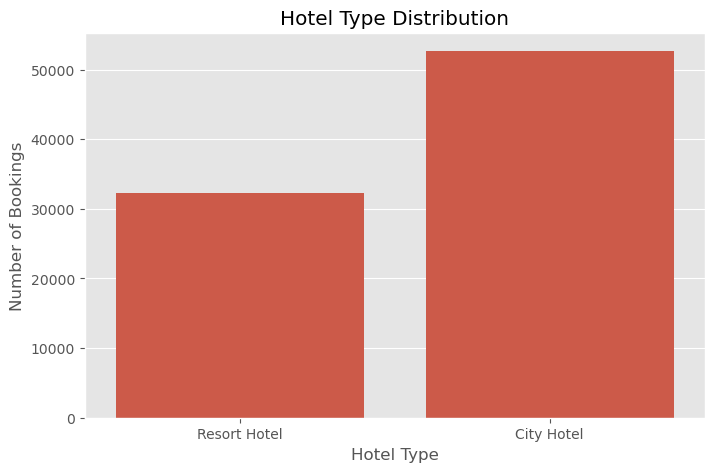

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel'
)

plt.title('Hotel Type Distribution')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

In [ ]:
#Cancellation Analysis-Important KPI Analysis

In [7]:
df['is_canceled'].value_counts()

is_canceled
0    61830
1    23059
Name: count, dtype: int64

In [8]:
cancel_rate = (df['is_canceled'].mean()) * 100

print("Cancellation Rate:", round(cancel_rate,2), "%")

Cancellation Rate: 27.16 %


In [ ]:
### Observation
Out of 84,889 bookings, 23,059 bookings were cancelled.
The overall cancellation rate is 27.16%, indicating that approximately one out of every four bookings does not result in a completed stay.
This suggests that cancellation behavior is a significant business concern and requires further investigation to identify the factors contributing to cancellations.

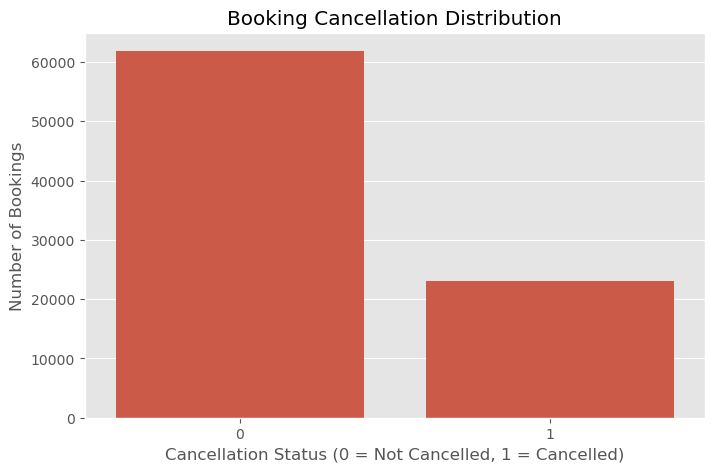

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='is_canceled')

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status (0 = Not Cancelled, 1 = Cancelled)')
plt.ylabel('Number of Bookings')

plt.show()

In [ ]:
### Observation
The majority of bookings were successfully completed, while a considerable portion of bookings were cancelled.
The high cancellation volume highlights the need to understand customer behavior and identify patterns associated with cancellations.

In [ ]:
#Hotel Type vs Cancellation

In [10]:
pd.crosstab(df['hotel'], df['is_canceled'])

is_canceled,0,1
hotel,,
City Hotel,36882,15769
Resort Hotel,24948,7290


In [ ]:
### Observation
City Hotel recorded the highest number of cancellations (15,769) compared to Resort Hotel (7,290).
Although City Hotel also receives more bookings overall, it experiences a substantially higher cancellation volume.
This suggests that customer behavior, booking patterns, or pricing strategies in City Hotels may contribute to increased cancellation risk.

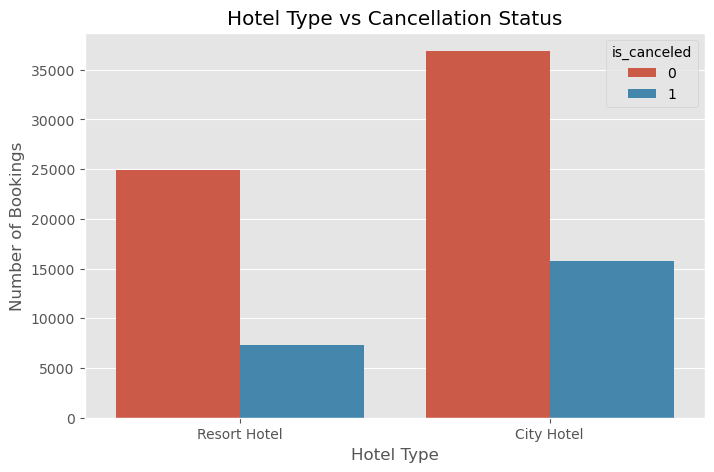

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title('Hotel Type vs Cancellation Status')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

In [ ]:
#Calculate Cancellation Rate by Hotel

In [13]:
hotel_cancel_rate = pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

hotel_cancel_rate

is_canceled,0,1
hotel,,
City Hotel,70.049952,29.950048
Resort Hotel,77.386935,22.613065


In [ ]:
#Monthly Booking Trend

In [15]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       9869
July         9491
May          8237
April        7831
June         7613
March        7485
October      6904
September    6619
February     6081
December     5082
November     4989
January      4688
Name: count, dtype: int64

In [ ]:
### Observation
August recorded the highest number of bookings (9,869), followed by July (9,491).
January had the lowest number of bookings (4,688).
This suggests that demand is highest during the summer vacation period, indicating a seasonal booking pattern in the hospitality industry.

In [ ]:
#Lead Time vs Cancellation

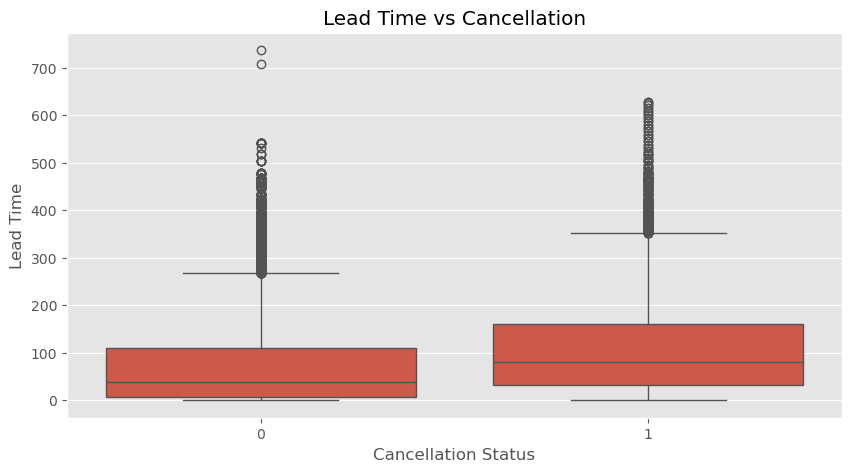

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time'
)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time')

plt.show()

In [17]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     70.38690
1    106.33024
Name: lead_time, dtype: float64

In [ ]:
### Observation
Customers who cancelled their bookings had a significantly higher average lead time (106.33 days) compared to customers who completed their stays (70.39 days).
This suggests that bookings made far in advance are more likely to be cancelled, possibly because customers have more time to change their travel plans.
Lead time appears to be an important predictor of booking cancellations and should be considered in future cancellation prediction models.

In [ ]:
#Market Segment Analysis

In [18]:
df['market_segment'].value_counts()

market_segment
Online TA        49842
Offline TA/TO    13835
Direct           11164
Groups            4915
Corporate         4202
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

In [ ]:
### Observation
Online Travel Agencies (Online TA) account for the highest number of bookings with 49,842 reservations, representing the dominant booking channel.
Offline Travel Agencies (Offline TA/TO) and Direct bookings are the second and third largest sources of reservations.
This indicates that online booking platforms play a critical role in customer acquisition and should be a primary focus for revenue management and retention strategies.

In [ ]:
#Market Segment Visualization

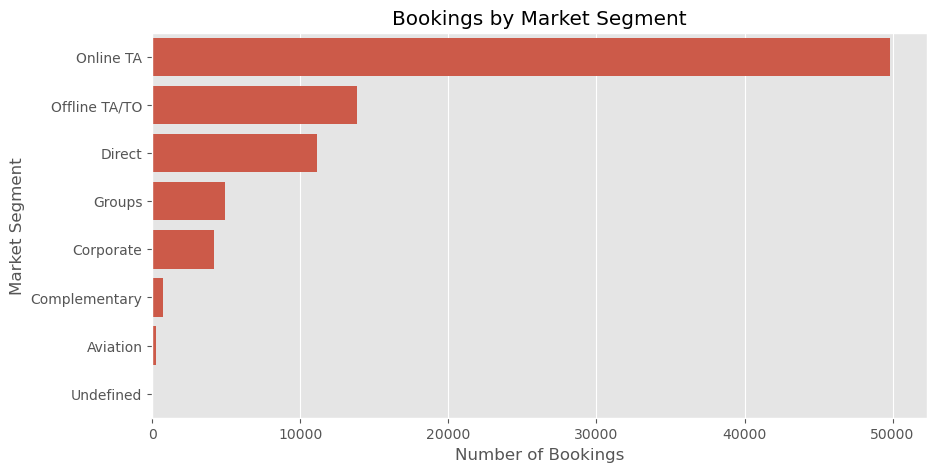

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.title('Bookings by Market Segment')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')

plt.show()

In [ ]:
#ADR (Average Daily Rate) Analysis

In [20]:
df['adr'].describe()

count    84889.000000
mean       101.788429
std         45.205950
min         -6.380000
25%         71.100000
50%         96.530000
75%        130.000000
max        227.000000
Name: adr, dtype: float64

In [ ]:
### Observation
The Average Daily Rate (ADR) has a mean value of 101.79 and a median value of 96.53.
Most room prices fall between 71 and 130, indicating a moderately priced hotel market.
The maximum ADR after outlier treatment is 227, suggesting that extremely high room prices were successfully removed during data cleaning.
ADR is a critical variable for revenue management and dynamic pricing strategies because it directly influences hotel revenue.

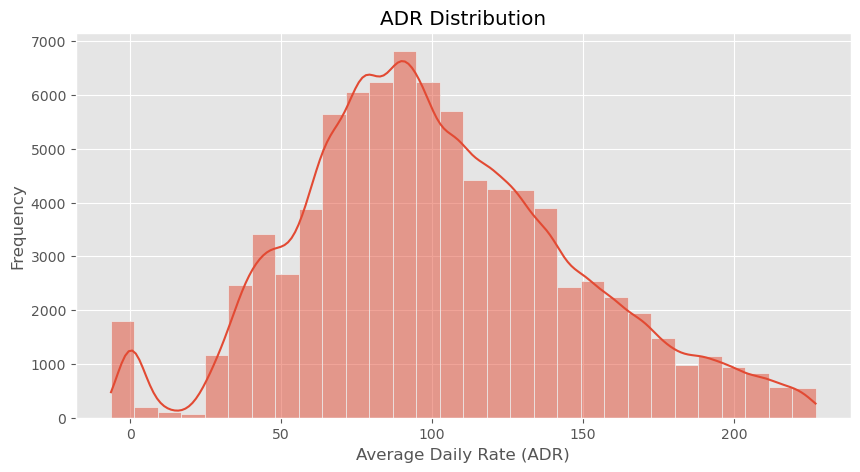

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df['adr'], bins=30, kde=True)

plt.title('ADR Distribution')
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Frequency')

plt.show()

In [ ]:
#Correlation Heatmap

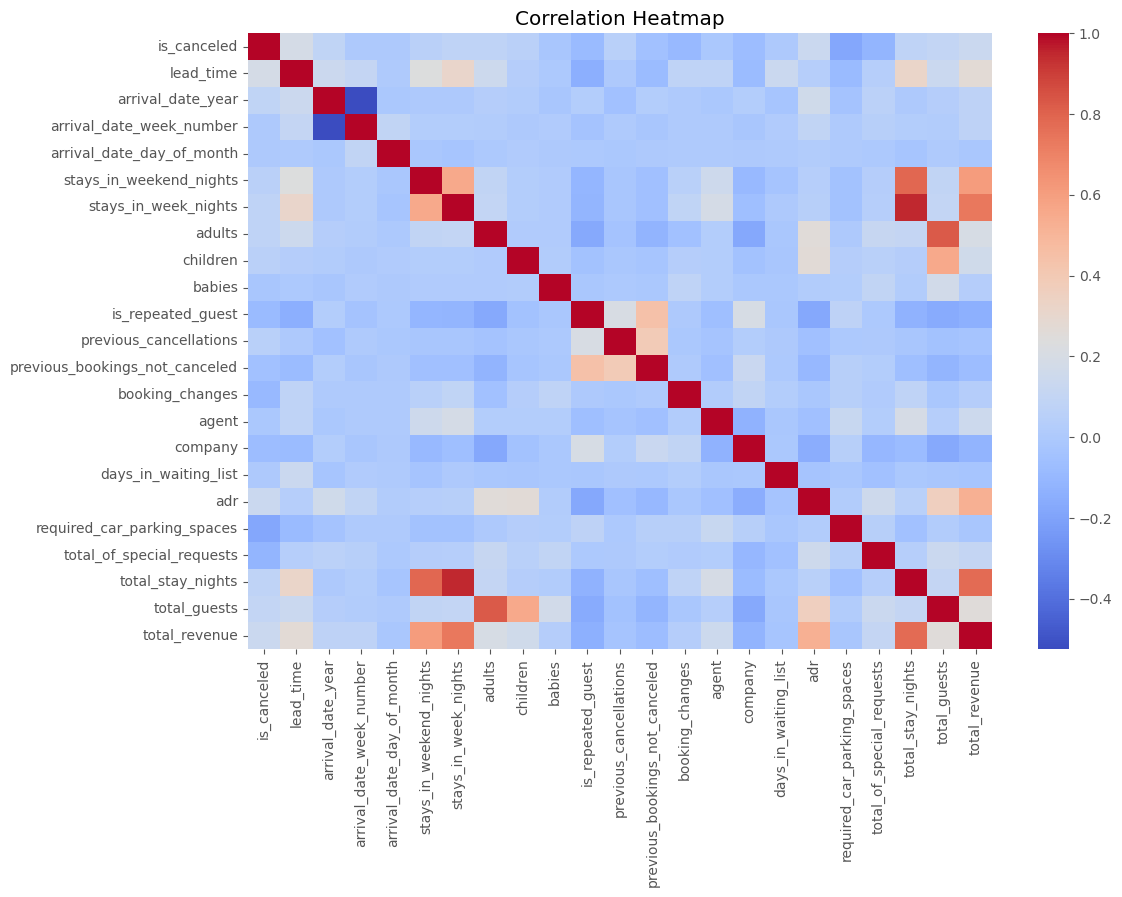

In [22]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

In [23]:
numeric_df.corr()['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184915
adr                               0.133684
total_revenue                     0.133211
total_guests                      0.095180
arrival_date_year                 0.084465
adults                            0.081735
total_stay_nights                 0.080365
stays_in_week_nights              0.079605
children                          0.057614
stays_in_weekend_nights           0.056796
previous_cancellations            0.052590
days_in_waiting_list              0.005320
arrival_date_day_of_month         0.004152
arrival_date_week_number         -0.000482
agent                            -0.009257
babies                           -0.019460
previous_bookings_not_canceled   -0.052150
company                          -0.074887
is_repeated_guest                -0.089341
booking_changes                  -0.092050
total_of_special_requests        -0.115422
required_car_parking_spaces      -0.180017
Name: is_ca

In [ ]:
#Key Business Insights

1. City Hotels have a higher cancellation rate than Resort Hotels.
2. Customers with higher lead times are more likely to cancel bookings.
3. Online TA is the dominant booking channel.
4. ADR has a positive relationship with cancellations.
5. Special requests and parking requirements are associated with lower cancellation rates.